# 06 — Fundamentals: the company behind the ticker

## What you'll learn
- What the **income statement**, **balance sheet**, and **cash-flow statement** each tell you, and how to read them in a DataFrame (fiscal periods are the *columns*, line items the *rows*).
- How to pull a company's financials and a Yahoo summary (`marketCap`, trailing `P/E`, shares outstanding) with `stocklearn.fundamentals`.
- The six headline ratios — **P/E, EPS, ROE, debt-to-equity, gross margin, current ratio** — and exactly how each is computed.
- How to compare two companies side by side, and why a ratio means nothing without peers, history, and industry context.
- How to chart P/E and ROE when their units differ (a multiple vs a percentage).

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from stocklearn.fundamentals import get_financials, compute_ratios

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

# Swap these two symbols to compare any pair of companies.
ticker = "AAPL"
other = "MSFT"


The line above is the only place you edit the symbol — everything below follows `ticker`, with
`other` as the peer company.

## Three statements, three questions

Fundamentals are the company's *actual business numbers* (unlike prices, which are what the market
is willing to pay). They arrive as three statements:

| Statement | Question it answers | Shape of the data |
|---|---|---|
| **Income statement** | Did the company make a profit this period? | Revenue, costs, profit — a *flow* over a period |
| **Balance sheet** | What does it own and owe *right now*? | Assets, liabilities, equity — a *snapshot* at a date |
| **Cash-flow statement** | Did cash actually move, and from where? | Operating / investing / financing cash flows |

`get_financials` returns each as a DataFrame whose **rows are line items** and whose **columns are
fiscal periods, newest first**. So the leftmost column is the most recent year. We transpose with
`.T` so each fiscal period becomes a row you can scan across — much easier to read.

In [2]:
fin = get_financials(ticker)

print(f"{ticker} income statement — columns are fiscal periods, newest first (leftmost).")
fin["income_stmt"].T


AAPL income statement — columns are fiscal periods, newest first (leftmost).


,Tax Effect Of Unusual Items,Tax Rate For Calcs,Normalized EBITDA,Net Income From Continuing Operation Net Minority Interest,Reconciled Depreciation,Reconciled Cost Of Revenue,EBITDA,EBIT,Net Interest Income,Interest Expense,Interest Income,Normalized Income,Net Income From Continuing And Discontinued Operation,Total Expenses,Total Operating Income As Reported,Diluted Average Shares,Basic Average Shares,Diluted EPS,Basic EPS,Diluted NI Availto Com Stockholders,Net Income Common Stockholders,Net Income,Net Income Including Noncontrolling Interests,Net Income Continuous Operations,Tax Provision,Pretax Income,Other Income Expense,Other Non Operating Income Expenses,Net Non Operating Interest Income Expense,Interest Expense Non Operating,Interest Income Non Operating,Operating Income,Operating Expense,Research And Development,Selling General And Administration,Gross Profit,Cost Of Revenue,Total Revenue,Operating Revenue
2025-09-30,0.0,0.156,1.447480e+11,1.120100e+11,1.169800e+10,2.209600e+11,1.447480e+11,1.330500e+11,NaN,NaN,NaN,1.120100e+11,1.120100e+11,2.831110e+11,1.330500e+11,1.500470e+10,1.494850e+10,7.46,7.49,1.120100e+11,1.120100e+11,1.120100e+11,1.120100e+11,1.120100e+11,2.071900e+10,1.327290e+11,-321000000.0,-321000000.0,NaN,NaN,NaN,1.330500e+11,6.215100e+10,3.455000e+10,2.760100e+10,1.952010e+11,2.209600e+11,4.161610e+11,4.161610e+11
2024-09-30,0.0,0.241,1.346610e+11,9.373600e+10,1.144500e+10,2.103520e+11,1.346610e+11,1.232160e+11,NaN,NaN,NaN,9.373600e+10,9.373600e+10,2.678190e+11,1.232160e+11,1.540810e+10,1.534378e+10,6.08,6.11,9.373600e+10,9.373600e+10,9.373600e+10,9.373600e+10,9.373600e+10,2.974900e+10,1.234850e+11,269000000.0,269000000.0,NaN,NaN,NaN,1.232160e+11,5.746700e+10,3.137000e+10,2.609700e+10,1.806830e+11,2.103520e+11,3.910350e+11,3.910350e+11
2023-09-30,0.0,0.147,1.258200e+11,9.699500e+10,1.151900e+10,2.141370e+11,1.258200e+11,1.143010e+11,-183000000.0,3.933000e+09,3.750000e+09,9.699500e+10,9.699500e+10,2.689840e+11,1.143010e+11,1.581255e+10,1.574423e+10,6.13,6.16,9.699500e+10,9.699500e+10,9.699500e+10,9.699500e+10,9.699500e+10,1.674100e+10,1.137360e+11,-565000000.0,-565000000.0,-183000000.0,3.933000e+09,3.750000e+09,1.143010e+11,5.484700e+10,2.991500e+10,2.493200e+10,1.691480e+11,2.141370e+11,3.832850e+11,3.832850e+11
2022-09-30,0.0,0.162,1.305410e+11,9.980300e+10,1.110400e+10,2.235460e+11,1.305410e+11,1.194370e+11,-106000000.0,2.931000e+09,2.825000e+09,9.980300e+10,9.980300e+10,2.748910e+11,1.194370e+11,1.632582e+10,1.621596e+10,6.11,6.15,9.980300e+10,9.980300e+10,9.980300e+10,9.980300e+10,9.980300e+10,1.930000e+10,1.191030e+11,-334000000.0,-334000000.0,-106000000.0,2.931000e+09,2.825000e+09,1.194370e+11,5.134500e+10,2.625100e+10,2.509400e+10,1.707820e+11,2.235460e+11,3.943280e+11,3.943280e+11


Read the income statement top-down as a funnel: **revenue** (total sales) minus **cost of revenue**
gives **gross profit**; subtract operating expenses to get **operating income**; then taxes,
interest and one-offs leave **net income**. Net income divided by the share count is **EPS**
(earnings per share) — the single number the market quotes most.

The **balance sheet** is a snapshot on a single date. Its accounting identity is
`assets = liabilities + equity`: everything the company owns was paid for either by borrowing
(liabilities) or by shareholders (equity).

In [3]:
fin["balance_sheet"].T


,Treasury Shares Number,Ordinary Shares Number,Share Issued,Net Debt,Total Debt,Tangible Book Value,Invested Capital,Working Capital,Net Tangible Assets,Capital Lease Obligations,Common Stock Equity,Total Capitalization,Total Equity Gross Minority Interest,Stockholders Equity,Gains Losses Not Affecting Retained Earnings,Other Equity Adjustments,Retained Earnings,Capital Stock,Common Stock,Total Liabilities Net Minority Interest,Total Non Current Liabilities Net Minority Interest,Other Non Current Liabilities,Tradeand Other Payables Non Current,Long Term Debt And Capital Lease Obligation,Long Term Capital Lease Obligation,Long Term Debt,Current Liabilities,Other Current Liabilities,Current Deferred Liabilities,Current Deferred Revenue,Current Debt And Capital Lease Obligation,Current Capital Lease Obligation,Current Debt,Other Current Borrowings,Commercial Paper,Payables And Accrued Expenses,Current Accrued Expenses,Payables,Total Tax Payable,Income Tax Payable,Accounts Payable,Total Assets,Total Non Current Assets,Other Non Current Assets,Non Current Deferred Assets,Non Current Deferred Taxes Assets,Investments And Advances,Other Investments,Investmentin Financial Assets,Available For Sale Securities,Net PPE,Accumulated Depreciation,Gross PPE,Leases,Other Properties,Machinery Furniture Equipment,Land And Improvements,Properties,Current Assets,Other Current Assets,Inventory,Receivables,Other Receivables,Accounts Receivable,Cash Cash Equivalents And Short Term Investments,Other Short Term Investments,Cash And Cash Equivalents,Cash Equivalents,Cash Financial
2025-09-30,NaN,1.477326e+10,1.477326e+10,6.272300e+10,9.865700e+10,7.373300e+10,1.723900e+11,-1.767400e+10,7.373300e+10,NaN,7.373300e+10,1.520610e+11,7.373300e+10,7.373300e+10,-5.571000e+09,-5.571000e+09,-1.426400e+10,9.356800e+10,9.356800e+10,2.855080e+11,1.198770e+11,4.154900e+10,NaN,7.832800e+10,NaN,7.832800e+10,1.656310e+11,4.445200e+10,9.055000e+09,9.055000e+09,2.032900e+10,NaN,2.032900e+10,1.235000e+10,7.979000e+09,9.179500e+10,8.919000e+09,8.287600e+10,1.301600e+10,1.301600e+10,6.986000e+10,3.592410e+11,2.112840e+11,6.295000e+10,2.077700e+10,2.077700e+10,7.772300e+10,NaN,7.772300e+10,7.772300e+10,4.983400e+10,-7.601400e+10,1.258480e+11,1.509100e+10,NaN,8.342000e+10,2.733700e+10,0.0,1.479570e+11,1.458500e+10,5.718000e+09,7.295700e+10,3.318000e+10,3.977700e+10,5.469700e+10,1.876300e+10,3.593400e+10,7.667000e+09,2.826700e+10
2024-09-30,NaN,1.511679e+10,1.511679e+10,7.668600e+10,1.066290e+11,5.695000e+10,1.635790e+11,-2.340500e+10,5.695000e+10,NaN,5.695000e+10,1.427000e+11,5.695000e+10,5.695000e+10,-7.172000e+09,-7.172000e+09,-1.915400e+10,8.327600e+10,8.327600e+10,3.080300e+11,1.316380e+11,4.588800e+10,9.254000e+09,8.575000e+10,NaN,8.575000e+10,1.763920e+11,4.402400e+10,8.249000e+09,8.249000e+09,2.087900e+10,NaN,2.087900e+10,1.091200e+10,9.967000e+09,1.032400e+11,NaN,9.556100e+10,2.660100e+10,2.660100e+10,6.896000e+10,3.649800e+11,2.119930e+11,5.533500e+10,1.949900e+10,1.949900e+10,9.147900e+10,NaN,9.147900e+10,9.147900e+10,4.568000e+10,-7.344800e+10,1.191280e+11,1.423300e+10,NaN,8.020500e+10,2.469000e+10,0.0,1.529870e+11,1.428700e+10,7.286000e+09,6.624300e+10,3.283300e+10,3.341000e+10,6.517100e+10,3.522800e+10,2.994300e+10,2.744000e+09,2.719900e+10
2023-09-30,0.0,1.555006e+10,1.555006e+10,8.112300e+10,1.110880e+11,6.214600e+10,1.732340e+11,-1.742000e+09,6.214600e+10,1.284200e+10,6.214600e+10,1.574270e+11,6.214600e+10,6.214600e+10,-1.145200e+10,-1.145200e+10,-2.140000e+08,7.381200e+10,7.381200e+10,2.904370e+11,1.451290e+11,3.439100e+10,1.545700e+10,9.528100e+10,1.126700e+10,9.528100e+10,1.453080e+11,5.001000e+10,8.061000e+09,8.061000e+09,1.580700e+10,1.575000e+09,1.580700e+10,9.822000e+09,5.985000e+09,7.143000e+10,NaN,7.143000e+10,8.819000e+09,8.819000e+09,6.261100e+10,3.525830e+11,2.090170e+11,4.690600e+10,1.785200e+10,1.785200e+10,1.005440e+11,NaN,1.005440e+11,1.005440e+11,4.371500e+10,-7.088400e+10,1.145990e+11,1.283900e+10,1.066100e+10,7.831400e+10,2.344600e+10,0.0,1.

Now the cash-flow statement. **Operating cash flow** is cash generated by the core business;
**investing** is buying or selling long-term assets (capital expenditure appears here as a negative);
**financing** is raising or returning money (debt, buybacks, dividends). A company can report a paper
profit and still run out of cash — this is the statement where you catch that.

In [4]:
fin["cashflow"].T


,Free Cash Flow,Repurchase Of Capital Stock,Repayment Of Debt,Issuance Of Debt,Capital Expenditure,Interest Paid Supplemental Data,Income Tax Paid Supplemental Data,End Cash Position,Beginning Cash Position,Changes In Cash,Financing Cash Flow,Cash Flow From Continuing Financing Activities,Net Other Financing Charges,Cash Dividends Paid,Common Stock Dividend Paid,Net Common Stock Issuance,Common Stock Payments,Net Issuance Payments Of Debt,Net Short Term Debt Issuance,Net Long Term Debt Issuance,Long Term Debt Payments,Long Term Debt Issuance,Investing Cash Flow,Cash Flow From Continuing Investing Activities,Net Other Investing Changes,Net Investment Purchase And Sale,Sale Of Investment,Purchase Of Investment,Net Business Purchase And Sale,Purchase Of Business,Net PPE Purchase And Sale,Purchase Of PPE,Operating Cash Flow,Cash Flow From Continuing Operating Activities,Change In Working Capital,Change In Other Working Capital,Change In Other Current Liabilities,Change In Other Current Assets,Change In Payables And Accrued Expense,Change In Payable,Change In Account Payable,Change In Inventory,Change In Receivables,Changes In Account Receivables,Other Non Cash Items,Stock Based Compensation,Deferred Tax,Deferred Income Tax,Depreciation Amortization Depletion,Depreciation And Amortization,Net Income From Continuing Operations
2025-09-30,9.876700e+10,-9.071100e+10,-1.093200e+10,4.481000e+09,-1.271500e+10,NaN,4.336900e+10,3.593400e+10,2.994300e+10,5.991000e+09,-1.206860e+11,-1.206860e+11,-6.071000e+09,-1.542100e+10,-1.542100e+10,-9.071100e+10,-9.071100e+10,-8.483000e+09,-2.032000e+09,-6.451000e+09,-1.093200e+10,4.481000e+09,1.519500e+10,1.519500e+10,-1.480000e+09,2.939000e+10,5.379700e+10,-2.440700e+10,NaN,NaN,-1.271500e+10,-1.271500e+10,1.114820e+11,1.114820e+11,-2.500000e+10,NaN,-1.107600e+10,-9.197000e+09,9.020000e+08,9.020000e+08,9.020000e+08,1.400000e+09,-7.029000e+09,-6.682000e+09,-8.900000e+07,1.286300e+10,NaN,NaN,1.169800e+10,1.169800e+10,1.120100e+11
2024-09-30,1.088070e+11,-9.494900e+10,-9.958000e+09,0.000000e+00,-9.447000e+09,NaN,2.610200e+10,2.994300e+10,3.073700e+10,-7.940000e+08,-1.219830e+11,-1.219830e+11,-5.802000e+09,-1.523400e+10,-1.523400e+10,-9.494900e+10,-9.494900e+10,-5.998000e+09,3.960000e+09,-9.958000e+09,-9.958000e+09,0.000000e+00,2.935000e+09,2.935000e+09,-1.308000e+09,1.369000e+10,6.234600e+10,-4.865600e+10,NaN,NaN,-9.447000e+09,-9.447000e+09,1.182540e+11,1.182540e+11,3.651000e+09,NaN,1.555200e+10,-1.173100e+10,6.020000e+09,6.020000e+09,6.020000e+09,-1.046000e+09,-5.144000e+09,-3.788000e+09,-2.266000e+09,1.168800e+10,NaN,NaN,1.144500e+10,1.144500e+10,9.373600e+10
2023-09-30,9.958400e+10,-7.755000e+10,-1.115100e+10,5.228000e+09,-1.095900e+10,3.803000e+09,1.867900e+10,3.073700e+10,2.497700e+10,5.760000e+09,-1.084880e+11,-1.084880e+11,-6.012000e+09,-1.502500e+10,-1.502500e+10,-7.755000e+10,-7.755000e+10,-9.901000e+09,-3.978000e+09,-5.923000e+09,-1.115100e+10,5.228000e+09,3.705000e+09,3.705000e+09,-1.337000e+09,1.600100e+10,4.551400e+10,-2.951300e+10,NaN,NaN,-1.095900e+10,-1.095900e+10,1.105430e+11,1.105430e+11,-6.577000e+09,NaN,3.031000e+09,-5.684000e+09,-1.889000e+09,-1.889000e+09,-1.889000e+09,-1.618000e+09,-4.170000e+08,-1.688000e+09,-2.227000e+09,1.083300e+10,NaN,NaN,1.151900e+10,1.151900e+10,9.699500e+10
2022-09-30,1.114430e+11,-8.940200e+10,-9.543000e+09,5.465000e+09,-1.070800e+10,2.865000e+09,1.957300e+10,2.497700e+10,3.592900e+10,-1.095200e+10,-1.107490e+11,-1.107490e+11,-6.383000e+09,-1.484100e+10,-1.484100e+10,-8.940200e+10,-8.940200e+10,-1.230000e+08,3.955000e+09,-4.078000e+09,-9.543000e+09,5.465000e+09,-2.235400e+10,-2.235400e+10,-2.086000e+09,-9.560000e+09,6.736300e+10,-7.692300e+10,-306000000.0,-306000000.0,-1.070800e+10,-1.070800e+10,1.221510e+11,1.221510e+11,1.200000e+09,478000000.0,6.110000e+09,-6.499000e+09,9.448000e+09,9.448000e+09,9.448000e+09,1.484000e+09,-9.343000e+09,-1.823000e+09,1.006000e+09,9.038000e+09,895000000.0,895000000.0,1.110400e+10,1.110400e+10,9.980300e+10


## The `.info` summary dict

Alongside the statements, Yahoo returns a flat dictionary of quick facts. It is a *summary* —
convenient, but not authoritative, and sometimes incomplete or stale. Treat it as a starting
point, not a source of truth.

In [5]:
info = fin["info"]
for key in ["shortName", "sector", "industry", "marketCap", "trailingPE",
            "sharesOutstanding", "dividendYield"]:
    print(f"{key:18} {info.get(key)}")


shortName          Apple Inc.
sector             Technology
industry           Consumer Electronics
marketCap          4869931925504
trailingPE         37.876274
sharesOutstanding  14594180000
dividendYield      0.32


## Six headline ratios, defined

`compute_ratios` derives six numbers from the statements plus `.info`. Definitions used here:

- **P/E** (price-to-earnings) = share price / earnings per share, taken from Yahoo's trailing figure.
  A *multiple*: how many dollars investors pay per dollar of annual profit. High = growth expected.
- **EPS** = net income / shares outstanding. Profit per share; the denominator of P/E.
- **ROE** (return on equity) = net income / shareholders' equity. How much profit the company squeezes
  from shareholders' money. Reported here as a **fraction** (0.30 = 30%).
- **Debt-to-equity** = total debt / equity. Leverage: above 1 means debt exceeds equity.
- **Gross margin** = gross profit / revenue. The share of each sales dollar left after direct costs.
- **Current ratio** = current assets / current liabilities. Can it pay this year's bills?
  Below 1 means short-term liabilities exceed short-term assets.

Every ratio uses the **most recent** fiscal period (the leftmost column).

In [6]:
ratios = {ticker: compute_ratios(ticker), other: compute_ratios(other)}

rows = ["pe_ratio", "eps", "roe", "debt_to_equity", "gross_margin", "current_ratio"]
comparison = pd.DataFrame(
    {ticker: [ratios[ticker][r] for r in rows],
     other:  [ratios[other][r]  for r in rows]},
    index=rows,
)
comparison.index.name = "ratio"
comparison


,AAPL,MSFT
ratio,,
pe_ratio,37.876274,28.577030
eps,7.674977,18.012010
roe,1.519130,0.302335
debt_to_equity,1.338030,0.128453
gross_margin,0.469052,0.679441
current_ratio,0.893293,1.230327


### Two things to notice

1. **Context is everything.** A P/E of 38 is neither good nor bad on its own. A software company
   trading at 38 may be cheap versus its peers; a utility at 38 may be stretched. Compare against
   (a) the same company's history, (b) close peers, (c) the industry average.
2. **`None` means "input missing", never zero.** Yahoo periodically renames or drops line items.
   `compute_ratios` deliberately returns `None` rather than pretending the value is 0 — a zero would
   silently poison every comparison. We render `None` as "unavailable" below, and charts stay safe by
   replacing it with `NaN` (that bar is simply skipped).

In [7]:
# Readable view: None -> "unavailable" (no numbers are invented).
comparison.fillna("unavailable")


,AAPL,MSFT
ratio,,
pe_ratio,37.876274,28.577030
eps,7.674977,18.012010
roe,1.519130,0.302335
debt_to_equity,1.338030,0.128453
gross_margin,0.469052,0.679441
current_ratio,0.893293,1.230327


In [8]:
# Demonstrate the None path without touching the real data: blank out one ratio.
def num(d, key):
    """Ratio -> float, or NaN when the input was missing (None)."""
    v = d.get(key)
    return np.nan if v is None else float(v)

broken = dict(ratios[ticker])
broken["pe_ratio"] = None          # pretend Yahoo stopped reporting a P/E
print("P/E value:", broken["pe_ratio"], "-> chart value:", num(broken, "pe_ratio"))


P/E value: None -> chart value: nan


## Charting P/E and ROE

P/E is a **multiple** (roughly 20–40) and ROE is a **percentage**, so sharing one pair of axes would
squash one of them. We use **two subplots**, each with its own y-axis and unit label. Bar height is
`NaN` for any `None` input, so a missing ratio yields an empty slot instead of an exception or a
fake zero.

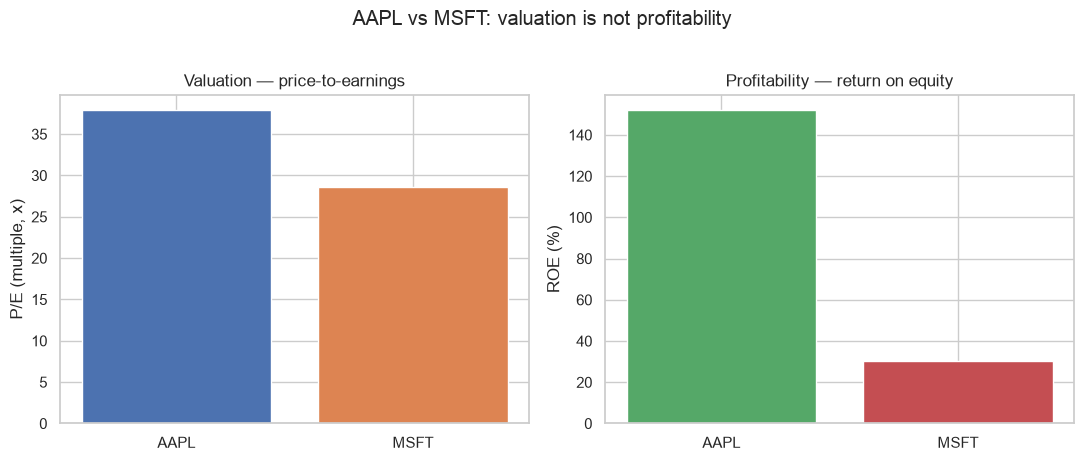

In [9]:
labels = [ticker, other]
pe_values  = [num(ratios[t], "pe_ratio") for t in labels]
roe_values = [num(ratios[t], "roe") * 100 for t in labels]   # fraction -> percent

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(labels, pe_values, color=sns.color_palette("deep")[:2])
axes[0].set_title("Valuation — price-to-earnings")
axes[0].set_ylabel("P/E (multiple, x)")

axes[1].bar(labels, roe_values, color=sns.color_palette("deep")[2:4])
axes[1].set_title("Profitability — return on equity")
axes[1].set_ylabel("ROE (%)")

plt.suptitle(f"{ticker} vs {other}: valuation is not profitability", y=1.02)
plt.tight_layout()
plt.show()


## Where fundamentals come from — and why they move slowly

These numbers originate in a company's **regulatory filings**: the annual **10-K** and the quarterly
**10-Q**, filed with the SEC. Data providers like Yahoo parse those documents and standardise the
line items.

That explains two things to keep in mind:

- **Fundamentals update quarterly or annually, not daily.** Prices change every second; P/E moves with
  the price even when earnings are frozen. Compare like-for-like fiscal periods.
- **Line-item names are not stable.** Yahoo adds and renames rows across versions — "Net Income" vs
  "Net Income Common Stockholders", "Total Debt" vs "Long Term Debt". Robust code tries several known
  names (as `stocklearn` does) instead of hard-coding one.

In [10]:
# See the naming for yourself: the raw line-item names in each statement.
for name in ("income_stmt", "balance_sheet", "cashflow"):
    items = list(fin[name].index)
    print(f"{name}: {len(items)} line items")
    print("   ", ", ".join(items[:8]), "...")


income_stmt: 39 line items
    Tax Effect Of Unusual Items, Tax Rate For Calcs, Normalized EBITDA, Net Income From Continuing Operation Net Minority Interest, Reconciled Depreciation, Reconciled Cost Of Revenue, EBITDA, EBIT ...
balance_sheet: 69 line items
    Treasury Shares Number, Ordinary Shares Number, Share Issued, Net Debt, Total Debt, Tangible Book Value, Invested Capital, Working Capital ...
cashflow: 51 line items
    Free Cash Flow, Repurchase Of Capital Stock, Repayment Of Debt, Issuance Of Debt, Capital Expenditure, Interest Paid Supplemental Data, Income Tax Paid Supplemental Data, End Cash Position ...


## Recap / try this
- Swap `other` to a competitor in the same industry (e.g. `"GOOGL"` for MSFT) and re-run: does the
  cheaper P/E company also have the higher ROE? Usually not — cheap and profitable are different things.
- Print `fin["income_stmt"].loc["Total Revenue"]` and compute year-over-year growth across the four
  annual columns; then do the same for net income.
- Change the chart to compare **gross margin** and **current ratio** instead — note again how the units
  differ and why separate axes matter.
- Deliberately pass a nonsense ticker to `compute_ratios` and inspect which values come back as `None`;
  confirm your code (and charts) still run.